<a href="https://colab.research.google.com/github/Akshatha7710/smart-tea-estate-management-system/blob/soil_quality-analysis_and_predictive_modeling/Soil_Quality_Analysis_and_Predictive_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.



Rainfall Forecast (Next 12 Months):
            ds        yhat  yhat_lower   yhat_upper
115 2025-11-01  464.619681  164.746478   752.661032
116 2025-12-01  234.164144  -55.208058   502.310481
117 2026-01-01   82.952444 -196.393874   375.328131
118 2026-02-01   77.679588 -231.370226   355.413060
119 2026-03-01  187.575135  -80.180298   480.374189
120 2026-04-01  304.663811   39.131817   580.567339
121 2026-05-01  852.062793  557.962255  1143.715781
122 2026-06-01  597.038261  307.996168   893.534762
123 2026-07-01  610.388716  299.933462   895.664043
124 2026-08-01  804.289734  527.070089  1100.930877
125 2026-09-01  494.151190  213.909670   779.087136
126 2026-10-01  629.322818  325.821877   909.729829

Wet Days Prediction Performance (XGBoost)
MAE: 3.5229045991664347
R2: 0.5380291757670896
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000260 seconds.
You can set `

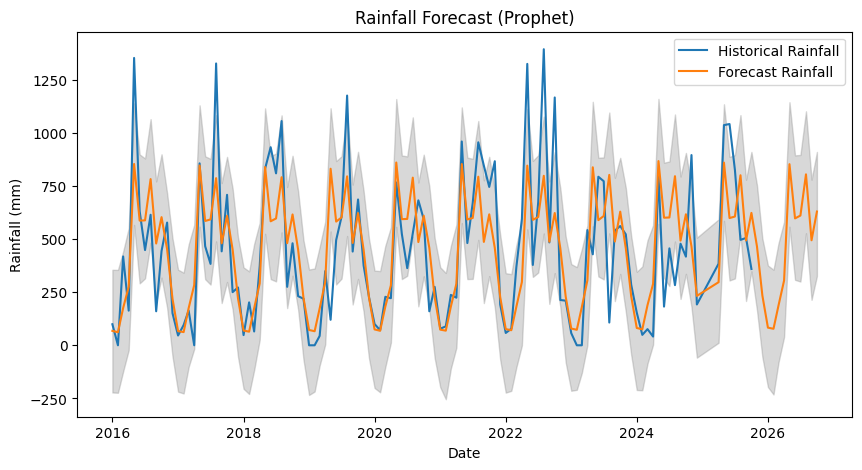

In [2]:
# ==========================================================
# STEMS - Smart Tea Estate Management System
# Improved Models: Prophet, XGBoost, LightGBM
# ==========================================================

# ==========================================================
# 1. Import Libraries
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

from prophet import Prophet
import xgboost as xgb
import lightgbm as lgb

# ==========================================================
# 2. Load Datasets
# ==========================================================
rainfall = pd.read_csv("sample_data/rainfall_data.csv")
soil = pd.read_csv("sample_data/soil_data.csv")

# ==========================================================
# 3. Rainfall Preprocessing
# ==========================================================
rainfall["Year"] = rainfall["Year"].str.split("/").str[0].astype(int)

month_map = {
    "January":1,"February":2,"March":3,"April":4,
    "May":5,"June":6,"July":7,"August":8,
    "September":9,"October":10,"November":11,"December":12
}

rainfall["Month"] = rainfall["Month"].map(month_map)
rainfall["Date"] = pd.to_datetime(dict(year=rainfall.Year, month=rainfall.Month, day=1))
rainfall = rainfall.sort_values("Date").dropna()

# ==========================================================
# 4. Rainfall Forecasting with Prophet
# ==========================================================
# Prepare Prophet format
rain_df = rainfall[["Date", "Rainfall"]].rename(columns={"Date":"ds", "Rainfall":"y"})

# Initialize and fit model
prophet_model = Prophet(yearly_seasonality=True, daily_seasonality=False)
prophet_model.fit(rain_df)

# Forecast next 12 months
future = prophet_model.make_future_dataframe(periods=12, freq='MS')
forecast = prophet_model.predict(future)

print("\nRainfall Forecast (Next 12 Months):")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12))

# ==========================================================
# 5. Wet Days Prediction with XGBoost
# ==========================================================
rainfall["Rainfall_lag1"] = rainfall["Rainfall"].shift(1)
rainfall["Rainfall_lag2"] = rainfall["Rainfall"].shift(2)
rainfall["Rainfall_3month_avg"] = rainfall["Rainfall"].rolling(3).mean()
rainfall = rainfall.dropna()

features = ["Rainfall", "Rainfall_lag1", "Rainfall_lag2", "Rainfall_3month_avg"]
X = rainfall[features]
y = rainfall["Wet_days"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)
wet_pred = xgb_model.predict(X_test)

print("\nWet Days Prediction Performance (XGBoost)")
print("MAE:", mean_absolute_error(y_test, wet_pred))
print("R2:", r2_score(y_test, wet_pred))

# ==========================================================
# 6. Soil pH Prediction with LightGBM
# ==========================================================
soil.replace("missing", np.nan, inplace=True)
soil["pH"] = pd.to_numeric(soil["pH"], errors="coerce")
soil["C%"] = pd.to_numeric(soil["C%"], errors="coerce")
soil["Year of Planting"] = pd.to_numeric(soil["Year of Planting"], errors="coerce")
soil = soil.dropna()

# Feature engineering
soil["FieldAge"] = 2025 - soil["Year of Planting"]

# Encode categorical variables
le = LabelEncoder()
soil["Category"] = le.fit_transform(soil["Category"])
soil["Estate"] = le.fit_transform(soil["Estate"])
soil["VP/SD"] = le.fit_transform(soil["VP/SD"])

soil_features = ["Extent (Ha)", "Category", "VP/SD", "FieldAge", "C%"]
X_soil = soil[soil_features]
y_soil = soil["pH"]

X_train, X_test, y_train, y_test = train_test_split(X_soil, y_soil, test_size=0.2, random_state=42)

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    random_state=42
)

lgb_model.fit(X_train, y_train)
soil_pred = lgb_model.predict(X_test)

print("\nSoil pH Prediction Performance (LightGBM)")
print("MAE:", mean_absolute_error(y_test, soil_pred))
print("R2:", r2_score(y_test, soil_pred))

# ==========================================================
# 7. Visualization
# ==========================================================
plt.figure(figsize=(10,5))
plt.plot(rain_df['ds'], rain_df['y'], label="Historical Rainfall")
plt.plot(forecast['ds'], forecast['yhat'], label="Forecast Rainfall")
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='gray', alpha=0.3)
plt.title("Rainfall Forecast (Prophet)")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.show()